1. Pobierz dane ze strony <a href="https://www.kaggle.com/datasets/spittman1248/cdc-data-nutrition-physical-activity-obesity">cdc-data-nutrition-physical-activity-obesity</a> i zbuduj modele regresji liniowej w 2D pokazującej zależność otyłości od trzech wybranych czynników (<a href="https://pl.wikipedia.org/wiki/Regresja_liniowa">Regresja liniowa.</a>).  Do budowy modelu użyj dwóch scenariuszy: wyprowadzenia teoretycznego przez metodę <a href="https://www.math.uni.wroc.pl/~topolski/Ekonometria_2.pdf">najmniejszych kwadratów</a> (dla chętnych) oraz <a href="https://www.geeksforgeeks.org/gradient-descent-in-linear-regression/">algorytmu gradientu prostego</a> (metoda obowiązkowa).
Pokaż wizualizację danych.     
2. Przeanalizuj, czy z punktu widzenia marketingowego producentowi Coca-Coli bardziej opłaca się zwiększyć promień puszki, czy też jej wysokość. W reklamie ma się pojawić komunikat o "większej objętości puszki" (wskazówka: różniczka funkcji dwóch zmiennych). Rozwiązanie powinno zawierać wszystkie obliczenia i konkluzje (Markdown)

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [95]:

class LinearRegression:
  def __init__(self, learning_rate=0.01):
    self.a = 0.0
    self.b = 0.0
    self.learning_rate = learning_rate
    self.data = None

  def calculate_gradient(self, data: np.array):
    x = data[:, 0]
    y = data[:, 1]
    n = len(x)

    y_pred = self.a * x + self.b

    delta_a = (2 / n) * np.sum((y_pred - y) * x)
    delta_b = (2 / n) * np.sum(y_pred - y)

    return delta_a, delta_b

  def learn(self, data: np.array, epochs=1000):
    self.data = data.astype(float)

    for _ in range(epochs):
      delta_a, delta_b = self.calculate_gradient(self.data)
      self.a -= self.learning_rate * delta_a
      self.b -= self.learning_rate * delta_b

  def show(self):
    x = self.data[:, 0]
    y = self.data[:, 1]

    plt.scatter(x, y, label="Dane")

    X_line = np.linspace(x.min(), x.max(), 100)
    y_line = self.a * X_line + self.b

    print("a =", self.a, "b =", self.b)

    plt.plot(X_line, y_line, color="red", label="Regresja liniowa")
    plt.legend()
    plt.show()

a = -0.06879076327579467 b = 30.58659972744559


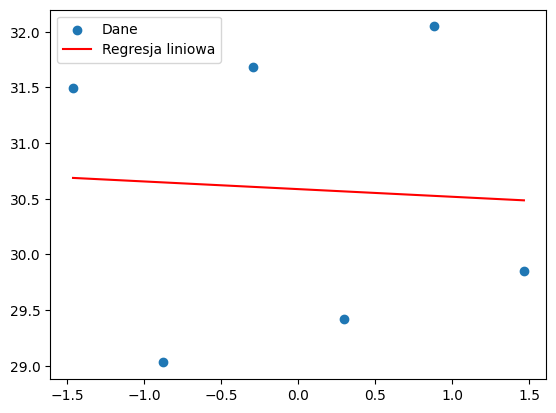

In [98]:
file = pd.read_csv("data.csv")

# 2. płeć
# 3. otyłość %



df = file[["YearStart", "Data_Value"]].dropna()
df_year = (df.groupby("YearStart", as_index=False).mean(numeric_only=True))
data = df_year.to_numpy(dtype=float)
data[:, 0] = (data[:, 0] - data[:, 0].mean()) / data[:, 0].std()

a = LinearRegression(0.01)
a.learn(data)
a.show()
